# Chronic Kidney Disease Clinical Analysis

This project analyses clinical data to investigate factors associated with chronic kidney disease.

The analysis focuses on exploratory data analysis and statistical hypothesis testing using Python.

The aim is to identify differences and associations between clinical characteristics and chronic kidney disease status, while considering both statistical significance and practical relevance.

## Introduction

Chronic kidney disease (CKD) is a long-term condition in which kidney function becomes impaired over time.

Clinical measurements such as serum creatinine, blood urea, haemoglobin and blood pressure can provide useful information about a patient's health status.

This project uses a clinical dataset containing demographic, laboratory and patient-history variables to investigate which characteristics are associated with chronic kidney disease.

The analysis will focus on statistical relationships rather than developing a predictive machine-learning model.

## Objective

The objective of this project is to investigate relationships between clinical characteristics and chronic kidney disease status.

The analysis will focus on the following questions:

- Do clinical measurements differ between patients with and without chronic kidney disease?
- Are conditions such as hypertension and diabetes associated with chronic kidney disease?
- Which clinical variables show the strongest statistical differences between the two groups?
- Are statistically significant findings also meaningful in practical or clinical terms?

Statistical hypothesis tests will be used to assess the evidence for relationships identified during exploratory analysis.

## Dataset

The dataset contains clinical information for individuals classified according to whether they have chronic kidney disease.

Variables include demographic characteristics, laboratory measurements, medical conditions and other clinical indicators.

The target variable is the chronic kidney disease classification.

Before conducting the analysis, the dataset will be inspected for missing values, duplicate records, inconsistent data types and other data-quality issues.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
df = pd.read_csv("data/chronic_kidney_disease.csv")

In [3]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
df.shape

(400, 26)

In [5]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

## Data Inspection

The dataset contains both numerical and categorical clinical variables.

The data types will be inspected before analysis to identify variables that may require conversion or cleaning.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [7]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [8]:
df["classification"].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [9]:
df["classification"].value_counts(normalize=True) * 100

classification
ckd       62.0
notckd    37.5
ckd\t      0.5
Name: proportion, dtype: float64

## Missing Values

Missing values are common in clinical datasets because not every measurement is necessarily available for every patient.

The number of missing values in each variable will be examined before deciding how the data should be handled.

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

rbc      152
rc       130
wc       105
pot       88
sod       87
pcv       70
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
ba         4
pcc        4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
rbc,152,38.00
rc,130,32.50
wc,105,26.25
pot,88,22.00
sod,87,21.75
pcv,70,17.50
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


## Duplicate Records

Duplicate records can affect statistical analysis by giving repeated observations disproportionate influence.

The dataset will therefore be checked for duplicate rows before cleaning.

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["id"].nunique(), df.shape[0]

(400, 400)

In [14]:
df["classification"].unique()

array(['ckd', 'ckd\t', 'notckd'], dtype=object)

In [15]:
df["classification"].str.len().value_counts()

classification
3    248
6    150
4      2
Name: count, dtype: int64

In [16]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [17]:
df["id"].nunique(), df.shape[0]

(400, 400)

In [18]:
categorical_columns = [
    "rbc", "pc", "pcc", "ba",
    "htn", "dm", "cad", "appet",
    "pe", "ane", "classification"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


rbc
rbc
normal      201
NaN         152
abnormal     47
Name: count, dtype: int64

pc
pc
normal      259
abnormal     76
NaN          65
Name: count, dtype: int64

pcc
pcc
notpresent    354
present        42
NaN             4
Name: count, dtype: int64

ba
ba
notpresent    374
present        22
NaN             4
Name: count, dtype: int64

htn
htn
no     251
yes    147
NaN      2
Name: count, dtype: int64

dm
dm
no       258
yes      134
\tno       3
\tyes      2
NaN        2
 yes       1
Name: count, dtype: int64

cad
cad
no      362
yes      34
\tno      2
NaN       2
Name: count, dtype: int64

appet
appet
good    317
poor     82
NaN       1
Name: count, dtype: int64

pe
pe
no     323
yes     76
NaN      1
Name: count, dtype: int64

ane
ane
no     339
yes     60
NaN      1
Name: count, dtype: int64

classification
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [19]:
numerical_columns = [
    "age", "bp", "sg", "al", "su",
    "bgr", "bu", "sc", "sod", "pot",
    "hemo", "pcv", "wc", "rc"
]

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


In [20]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


In [21]:
df[["pot", "sc", "bgr", "bu"]].sort_values("pot", ascending=False).head(10)

,pot,sc,bgr,bu
128,47.0,5.6,224.0,166.0
61,39.0,32.0,182.0,391.0
84,7.6,15.0,76.0,186.0
60,6.6,3.2,141.0,66.0
193,6.5,18.1,NaN,223.0
249,6.5,13.3,176.0,309.0
14,6.4,4.1,157.0,90.0
245,6.3,5.3,103.0,79.0
136,6.3,2.8,213.0,68.0
204,6.3,13.5,172.0,82.0


In [22]:
df[["pot", "sc", "bgr", "bu"]].sort_values("sc", ascending=False).head(10)

,pot,sc,bgr,bu
21,NaN,76.0,NaN,180.0
148,NaN,48.1,171.0,26.0
61,39.0,32.0,182.0,391.0
6,4.0,24.0,100.0,54.0
193,6.5,18.1,NaN,223.0
143,4.7,18.0,210.0,165.0
134,5.2,16.9,122.0,NaN
154,4.2,16.4,242.0,132.0
246,5.7,15.2,106.0,215.0
84,7.6,15.0,76.0,186.0


## Data Cleaning

The dataset contains several formatting inconsistencies in categorical variables, including leading or trailing whitespace and tab characters.

These inconsistencies will be standardised before analysis so that equivalent clinical categories are represented consistently.

The dataset also contains substantial missing data in several variables. Missing observations will not be removed globally because doing so would substantially reduce the available sample size. Instead, statistical analyses will use the available observations for the variables included in each analysis.

Extreme numerical values were also identified in variables such as serum creatinine, blood urea and potassium. These observations were retained because they occur alongside other clinically elevated measurements and may represent genuine clinical observations rather than data-entry errors.

The `id` variable will be retained in the raw dataset for record identification but excluded from the analytical dataset because it has no clinical meaning.

In [23]:
df_clean = df.copy()

In [24]:
categorical_columns = [
    "rbc", "pc", "pcc", "ba",
    "htn", "dm", "cad", "appet",
    "pe", "ane", "classification"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].str.strip()

In [25]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


rbc
rbc
normal      201
NaN         152
abnormal     47
Name: count, dtype: int64

pc
pc
normal      259
abnormal     76
NaN          65
Name: count, dtype: int64

pcc
pcc
notpresent    354
present        42
NaN             4
Name: count, dtype: int64

ba
ba
notpresent    374
present        22
NaN             4
Name: count, dtype: int64

htn
htn
no     251
yes    147
NaN      2
Name: count, dtype: int64

dm
dm
no     261
yes    137
NaN      2
Name: count, dtype: int64

cad
cad
no     364
yes     34
NaN      2
Name: count, dtype: int64

appet
appet
good    317
poor     82
NaN       1
Name: count, dtype: int64

pe
pe
no     323
yes     76
NaN      1
Name: count, dtype: int64

ane
ane
no     339
yes     60
NaN      1
Name: count, dtype: int64

classification
classification
ckd       250
notckd    150
Name: count, dtype: int64


In [26]:
df_analysis = df_clean.drop(columns="id").copy()

In [27]:
df_analysis.shape

(400, 25)

In [28]:
df_analysis["classification"].value_counts(dropna=False)

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [29]:
df_analysis.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

The exploratory analysis compares demographic characteristics, clinical measurements and medical conditions between patients with and without chronic kidney disease.

The aim is to identify patterns that may warrant formal statistical testing.

Particular attention will be given to laboratory measurements such as serum creatinine, blood urea, haemoglobin and blood glucose, as well as clinical conditions including hypertension and diabetes.

In [30]:
df_analysis.groupby("classification")[["age", "bp", "bgr", "bu", "sc", "hemo"]].describe()

age                                                      \
                count       mean        std   min   25%   50%   75%   max   
classification                                                              
ckd             242.0  54.541322  17.388899   2.0  47.0  59.0  66.0  90.0   
notckd          149.0  46.516779  15.631138  12.0  34.0  46.0  58.0  80.0   

                   bp             ...    sc         hemo                       \
                count       mean  ...   75%   max  count       mean       std   
classification                    ...                                           
ckd             240.0  79.625000  ...  4.55  76.0  204.0  10.647549  2.185790   
notckd          148.0  71.351351  ...  1.10   1.2  144.0  15.188194  1.277536   

                                                  
                 min     25%   50%     75%   max  
classification                                    
ckd              3.1   9.475  10.9  12.025  16.1  
notckd          13.0  14.100  15.0  16.200  17.8  

[2 rows x 48 columns]

<Figure size 700x500 with 0 Axes>

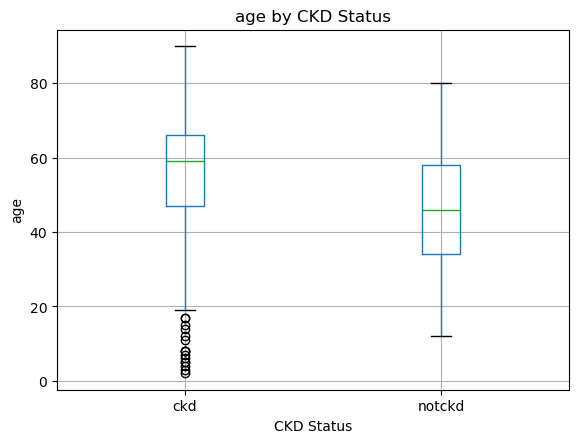

<Figure size 700x500 with 0 Axes>

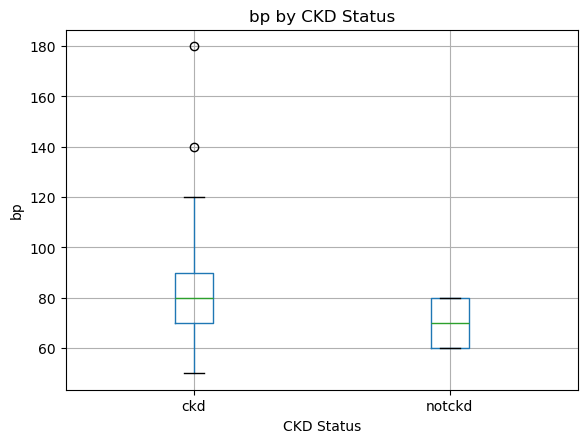

<Figure size 700x500 with 0 Axes>

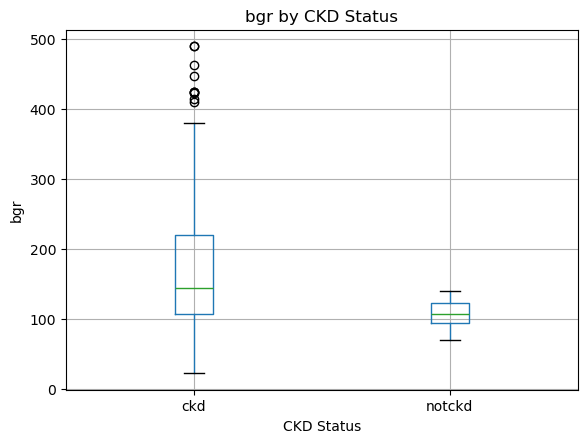

<Figure size 700x500 with 0 Axes>

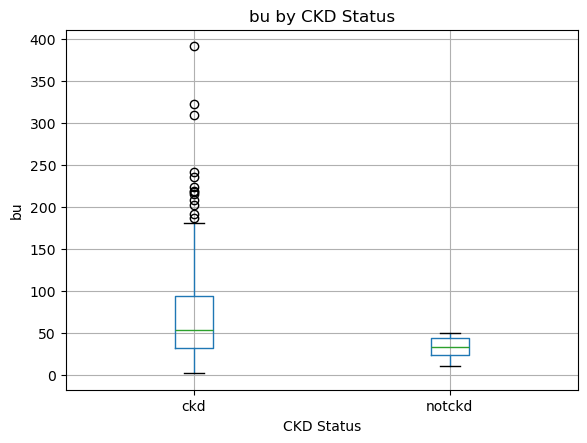

<Figure size 700x500 with 0 Axes>

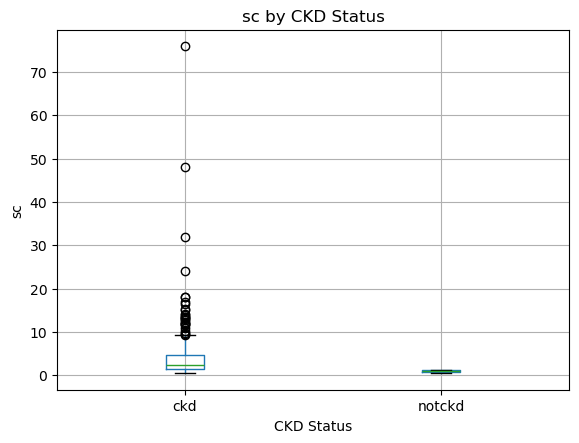

<Figure size 700x500 with 0 Axes>

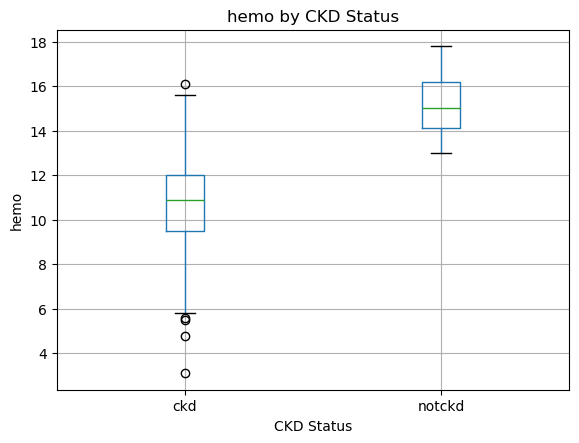

In [31]:
variables = ["age", "bp", "bgr", "bu", "sc", "hemo"]

for variable in variables:
    plt.figure(figsize=(7, 5))
    
    df_analysis.boxplot(
        column=variable,
        by="classification"
    )
    
    plt.title(f"{variable} by CKD Status")
    plt.suptitle("")
    plt.xlabel("CKD Status")
    plt.ylabel(variable)
    plt.show()

## Comparing Clinical Measurements

The distributions of key clinical measurements will now be compared between patients with and without chronic kidney disease.

Because several laboratory measurements are skewed and contain extreme observations, the median and interquartile range will be considered alongside the mean and standard deviation.

In [32]:
continuous_variables = ["age", "bp", "bgr", "bu", "sc", "hemo"]

summary = df_analysis.groupby("classification")[continuous_variables].agg(
    ["count", "mean", "median", "std"]
)

summary

age                                 bp                    \
               count       mean median        std count       mean median   
classification                                                              
ckd              242  54.541322   59.0  17.388899   240  79.625000   80.0   
notckd           149  46.516779   46.0  15.631138   148  71.351351   70.0   

                            bgr              ...     bu               sc  \
                      std count        mean  ... median        std count   
classification                               ...                           
ckd             15.234053   212  175.419811  ...   53.0  58.587236   238   
notckd           8.543498   144  107.722222  ...   33.0  11.450459   145   

                                           hemo                              
                    mean median       std count       mean median       std  
classification                                                               
ckd             4.414916   2.25  6.950275   204  10.647549   10.9  2.185790  
notckd          0.868966   0.90  0.255092   144  15.188194   15.0  1.277536  

[2 rows x 24 columns]

In [33]:
for variable in continuous_variables:
    ckd = df_analysis.loc[
        df_analysis["classification"] == "ckd", variable
    ].dropna()
    
    notckd = df_analysis.loc[
        df_analysis["classification"] == "notckd", variable
    ].dropna()
    
    print(f"\n{variable}")
    print(f"CKD     — n={len(ckd)}, median={ckd.median():.2f}")
    print(f"Not CKD — n={len(notckd)}, median={notckd.median():.2f}")


age
CKD     — n=242, median=59.00
Not CKD — n=149, median=46.00

bp
CKD     — n=240, median=80.00
Not CKD — n=148, median=70.00

bgr
CKD     — n=212, median=143.50
Not CKD — n=144, median=107.50

bu
CKD     — n=237, median=53.00
Not CKD — n=144, median=33.00

sc
CKD     — n=238, median=2.25
Not CKD — n=145, median=0.90

hemo
CKD     — n=204, median=10.90
Not CKD — n=144, median=15.00


## Initial EDA Findings

The exploratory analysis indicates noticeable differences in several clinical measurements between patients with chronic kidney disease and those without CKD.

The CKD group had higher median age, blood pressure, blood glucose, blood urea and serum creatinine than the non-CKD group.

Haemoglobin showed the opposite pattern, with a substantially lower median among patients with CKD.

The number of available observations varies between variables because of missing data. Therefore, subsequent statistical tests will use the available observations for each variable rather than removing all records with any missing value.

These observations are descriptive and do not establish that the measured clinical characteristics cause chronic kidney disease. Formal statistical testing will be used in the next stage of the analysis to determine whether the observed differences provide sufficient evidence of statistical association.

## Statistical Analysis

The exploratory analysis identified several differences between patients with and without chronic kidney disease.

Formal statistical hypothesis tests will now be used to assess whether these observed differences provide sufficient evidence of statistical association.

For continuous clinical variables, Welch's independent-samples t-test will be used to compare the CKD and non-CKD groups. Welch's t-test is appropriate when comparing two independent groups without assuming that the groups have equal variances.

For categorical variables, chi-square tests of independence will be used to assess whether conditions such as hypertension and diabetes are associated with CKD status.

A significance level of α = 0.05 will be used.

A statistically significant result will indicate evidence of an association or difference between groups, but it will not by itself demonstrate causation or clinical importance.

### Hypotheses

For continuous variables:

- **Null hypothesis (H₀):** The mean value is the same in patients with and without CKD.
- **Alternative hypothesis (H₁):** The mean value differs between patients with and without CKD.

For categorical variables:

- **Null hypothesis (H₀):** The clinical condition and CKD status are independent.
- **Alternative hypothesis (H₁):** The clinical condition and CKD status are associated.

In [34]:
continuous_variables = ["age", "bp", "bgr", "bu", "sc", "hemo"]

results = []

for variable in continuous_variables:
    ckd_values = df_analysis.loc[
        df_analysis["classification"] == "ckd", variable
    ].dropna()
    
    notckd_values = df_analysis.loc[
        df_analysis["classification"] == "notckd", variable
    ].dropna()
    
    statistic, p_value = stats.ttest_ind(
        ckd_values,
        notckd_values,
        equal_var=False
    )
    
    results.append({
        "Variable": variable,
        "CKD mean": ckd_values.mean(),
        "Not CKD mean": notckd_values.mean(),
        "t-statistic": statistic,
        "p-value": p_value
    })

continuous_results = pd.DataFrame(results)

continuous_results.round({
    "CKD mean": 2,
    "Not CKD mean": 2,
    "t-statistic": 2,
    "p-value": 2
})

,Variable,CKD mean,Not CKD mean,t-statistic,p-value
0,age,54.54,46.52,4.72,0.0
1,bp,79.62,71.35,6.85,0.0
2,bgr,175.42,107.72,10.40,0.0
3,bu,72.39,32.80,10.09,0.0
4,sc,4.41,0.87,7.86,0.0
5,hemo,10.65,15.19,-24.36,0.0


In [35]:
continuous_results["p-value"] = continuous_results["p-value"].map(
    lambda x: f"{x:.2e}"
)

continuous_results.round({
    "CKD mean": 2,
    "Not CKD mean": 2,
    "t-statistic": 2
})

,Variable,CKD mean,Not CKD mean,t-statistic,p-value
0,age,54.54,46.52,4.72,3.44e-06
1,bp,79.62,71.35,6.85,3.01e-11
2,bgr,175.42,107.72,10.40,4.35e-21
3,bu,72.39,32.80,10.09,1.80e-20
4,sc,4.41,0.87,7.86,1.31e-13
5,hemo,10.65,15.19,-24.36,3.61e-76


### Continuous Variable Test Results

Welch's t-tests identified statistically significant differences between the CKD and non-CKD groups for all six continuous variables examined.

Patients with CKD had higher mean age, blood pressure, blood glucose, blood urea and serum creatinine than patients without CKD. In contrast, mean haemoglobin was substantially lower in the CKD group.

All p-values were below the predefined significance level of α = 0.05, providing strong statistical evidence that these variables differ between the two groups.

The largest statistical evidence was observed for haemoglobin, although p-values alone do not indicate the magnitude or clinical importance of an effect. Effect sizes and confidence intervals will therefore be examined separately.

### Categorical Variable Analysis

Chi-square tests of independence will be used to investigate whether hypertension and diabetes are associated with chronic kidney disease status.

The null hypothesis assumes that the clinical condition and CKD status are independent.

The alternative hypothesis assumes that there is an association between the clinical condition and CKD status.

A significance level of α = 0.05 will be used.

In [36]:
categorical_variables = ["htn", "dm"]

categorical_results = []

for variable in categorical_variables:
    contingency_table = pd.crosstab(
        df_analysis[variable],
        df_analysis["classification"]
    )
    
    chi2, p_value, dof, expected = stats.chi2_contingency(
        contingency_table
    )
    
    categorical_results.append({
        "Variable": variable,
        "Chi-square statistic": chi2,
        "Degrees of freedom": dof,
        "p-value": p_value
    })

categorical_results = pd.DataFrame(categorical_results)

categorical_results

,Variable,Chi-square statistic,Degrees of freedom,p-value
0,htn,135.477426,1,2.596025e-31
1,dm,121.260097,1,3.351777e-28


In [37]:
for variable in categorical_variables:
    print(f"\n{variable.upper()}")
    
    proportions = pd.crosstab(
        df_analysis[variable],
        df_analysis["classification"],
        normalize="columns"
    ) * 100
    
    print(proportions.round(1))


HTN
classification   ckd  notckd
htn                         
no              41.2   100.0
yes             58.8     0.0

DM
classification   ckd  notckd
dm                          
no              45.2   100.0
yes             54.8     0.0


In [38]:
for variable in categorical_variables:
    print(f"\n{variable.upper()}")
    
    contingency_table = pd.crosstab(
        df_analysis[variable],
        df_analysis["classification"]
    )
    
    print(contingency_table)


HTN
classification  ckd  notckd
htn                        
no              103     148
yes             147       0

DM
classification  ckd  notckd
dm                         
no              113     148
yes             137       0


### Categorical Variable Test Results

Chi-square tests indicated statistically significant associations between both hypertension and diabetes and CKD status.

Hypertension showed a chi-square statistic of 135.48 with a p-value of 2.60 × 10⁻³¹. Diabetes showed a chi-square statistic of 121.26 with a p-value of 3.35 × 10⁻²⁸.

In the CKD group, 58.8% of observations were recorded as having hypertension and 54.8% as having diabetes. However, none of the observations in the non-CKD group were recorded as having either condition.

This perfect separation is an important characteristic of the dataset. Although the statistical tests provide strong evidence of an association within this sample, the unusual distribution means that these findings should not be interpreted as evidence that hypertension or diabetes independently causes CKD.

The results may partly reflect the way the dataset was collected or constructed and may limit how confidently these associations can be generalised to other clinical populations.

## Effect Sizes and Confidence Intervals

Statistical significance indicates whether there is evidence of a difference between groups, but it does not describe the magnitude or precision of that difference.

Effect sizes will therefore be calculated to quantify the size of the differences between patients with and without CKD.

For the continuous variables, Cohen's d will be used as a standardised measure of the difference between group means.

95% confidence intervals will also be calculated for the difference in group means. These intervals provide a range of plausible values for the population difference based on the sample data.

Effect sizes and confidence intervals will be interpreted alongside the hypothesis-test results rather than relying on p-values alone.

## Effect Sizes and Confidence Intervals

Statistical significance indicates whether there is evidence of a difference between groups, but it does not describe the magnitude or precision of that difference.

Effect sizes will therefore be calculated to quantify the size of the differences between patients with and without CKD.

For the continuous variables, Cohen's d will be used as a standardised measure of the difference between group means.

95% confidence intervals will also be calculated for the difference in group means. These intervals provide a range of plausible values for the population difference based on the sample data.

Effect sizes and confidence intervals will be interpreted alongside the hypothesis-test results rather than relying on p-values alone.

### Effect Sizes for Continuous Variables

In [39]:
effect_results = []

for variable in continuous_variables:
    ckd_values = df_analysis.loc[
        df_analysis["classification"] == "ckd", variable
    ].dropna()
    
    notckd_values = df_analysis.loc[
        df_analysis["classification"] == "notckd", variable
    ].dropna()
    
    n1 = len(ckd_values)
    n2 = len(notckd_values)
    
    mean1 = ckd_values.mean()
    mean2 = notckd_values.mean()
    
    sd1 = ckd_values.std()
    sd2 = notckd_values.std()
    
    pooled_sd = np.sqrt(
        ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
        / (n1 + n2 - 2)
    )
    
    cohens_d = (mean1 - mean2) / pooled_sd
    
    effect_results.append({
        "Variable": variable,
        "Cohen's d": cohens_d
    })

effect_results = pd.DataFrame(effect_results)

effect_results

,Variable,Cohen's d
0,age,0.479309
1,bp,0.631793
2,bgr,0.939414
3,bu,0.846607
4,sc,0.646608
5,hemo,-2.434872


### 95% Confidence Intervals

In [40]:
ci_results = []

for variable in continuous_variables:
    ckd_values = df_analysis.loc[
        df_analysis["classification"] == "ckd", variable
    ].dropna()
    
    notckd_values = df_analysis.loc[
        df_analysis["classification"] == "notckd", variable
    ].dropna()
    
    n1 = len(ckd_values)
    n2 = len(notckd_values)
    
    mean1 = ckd_values.mean()
    mean2 = notckd_values.mean()
    
    difference = mean1 - mean2
    
    se = np.sqrt(
        (ckd_values.var(ddof=1) / n1)
        + (notckd_values.var(ddof=1) / n2)
    )
    
    degrees_of_freedom = (
        (
            ckd_values.var(ddof=1) / n1
            + notckd_values.var(ddof=1) / n2
        ) ** 2
        /
        (
            (
                ckd_values.var(ddof=1) / n1
            ) ** 2 / (n1 - 1)
            +
            (
                notckd_values.var(ddof=1) / n2
            ) ** 2 / (n2 - 1)
        )
    )
    
    t_critical = stats.t.ppf(
        0.975,
        degrees_of_freedom
    )
    
    margin_of_error = t_critical * se
    
    lower_ci = difference - margin_of_error
    upper_ci = difference + margin_of_error
    
    ci_results.append({
        "Variable": variable,
        "Mean difference": difference,
        "95% CI lower": lower_ci,
        "95% CI upper": upper_ci
    })

ci_results = pd.DataFrame(ci_results)

ci_results

,Variable,Mean difference,95% CI lower,95% CI upper
0,age,8.024544,4.681065,11.368023
1,bp,8.273649,5.897769,10.649528
2,bgr,67.697589,54.870992,80.524186
3,bu,39.590418,31.865296,47.315541
4,sc,3.545950,2.657456,4.434445
5,hemo,-4.540645,-4.907353,-4.173938


### Combined Effect Size and Confidence Interval Results

In [41]:
effect_ci_results = continuous_results[
    ["Variable", "CKD mean", "Not CKD mean", "p-value"]
].merge(
    effect_results,
    on="Variable"
).merge(
    ci_results,
    on="Variable"
)

effect_ci_results

,Variable,CKD mean,Not CKD mean,p-value,Cohen's d,Mean difference,95% CI lower,95% CI upper
0,age,54.541322,46.516779,3.44e-06,0.479309,8.024544,4.681065,11.368023
1,bp,79.625000,71.351351,3.01e-11,0.631793,8.273649,5.897769,10.649528
2,bgr,175.419811,107.722222,4.35e-21,0.939414,67.697589,54.870992,80.524186
3,bu,72.389030,32.798611,1.80e-20,0.846607,39.590418,31.865296,47.315541
4,sc,4.414916,0.868966,1.31e-13,0.646608,3.545950,2.657456,4.434445
5,hemo,10.647549,15.188194,3.61e-76,-2.434872,-4.540645,-4.907353,-4.173938


### Effect Size and Confidence Interval Findings

The effect size analysis showed that the differences between the CKD and non-CKD groups varied substantially in magnitude.

Age and blood pressure showed moderate standardised differences, with Cohen's d values of 0.48 and 0.63 respectively.

Blood glucose, blood urea and serum creatinine showed larger standardised differences, with Cohen's d values of 0.94, 0.85 and 0.65 respectively.

Haemoglobin showed the largest standardised difference, with a Cohen's d of -2.43. The negative value reflects the substantially lower mean haemoglobin level in the CKD group.

The 95% confidence intervals for all six mean differences excluded zero, indicating that the observed differences were estimated with sufficient precision to provide evidence of differences between the groups in this sample.

The magnitude of these effects provides additional information beyond statistical significance. In particular, the large differences observed for blood glucose, blood urea and haemoglobin suggest that these variables show substantial separation between the CKD and non-CKD groups in this dataset.

However, effect sizes should be interpreted in the context of the dataset and its clinical characteristics. A large statistical effect does not by itself establish a causal relationship or determine whether a measurement is clinically useful for diagnosing or managing CKD.

## Statistical Findings

The statistical analysis identified clear differences between the CKD and non-CKD groups across all six continuous clinical variables examined.

Patients with CKD had higher mean age, blood pressure, blood glucose, blood urea and serum creatinine than patients without CKD. Haemoglobin was substantially lower in the CKD group.

All six continuous variables had p-values below the predefined significance level of α = 0.05. The 95% confidence intervals for the mean differences also excluded zero.

The effect size analysis showed that the magnitude of the differences varied between variables. Age and blood pressure demonstrated moderate standardised differences, while blood glucose, blood urea and serum creatinine showed larger standardised differences.

Haemoglobin showed the largest standardised difference, with a Cohen's d of -2.43, reflecting substantially lower haemoglobin levels in the CKD group.

The categorical analysis also identified statistically significant relationships between CKD status and both hypertension and diabetes. However, all non-CKD observations were recorded as having neither hypertension nor diabetes. This perfect separation is an important characteristic of the dataset and limits how broadly these categorical findings should be interpreted.

## Clinical Interpretation

The analysis demonstrates substantial differences in several clinical measurements between individuals classified as having CKD and those classified as not having CKD.

Serum creatinine and blood urea showed higher average values in the CKD group. These measurements are clinically relevant to kidney function because impaired kidney function can be associated with reduced clearance of metabolic waste products.

The CKD group also had substantially lower mean haemoglobin. The large effect size observed for haemoglobin indicates that the difference between the groups was not only statistically significant but also large relative to the variability within the sample.

Blood glucose showed a large standardised difference between the groups, with higher mean values among observations classified as CKD. This indicates that abnormal glucose measurements were more common or more pronounced in the CKD group within this dataset.

The CKD group also had higher average blood pressure and age. These findings indicate that the two groups differed across several demographic and clinical characteristics rather than being separated by a single measurement.

The associations identified in this analysis should not be interpreted as evidence that any individual variable causes CKD. The analysis is observational and does not control for potential confounding factors or establish temporal relationships.

Overall, the results suggest that CKD status in this dataset is associated with a broad pattern of differences across renal, haematological, metabolic and demographic measurements.

## Limitations

Several limitations should be considered when interpreting the findings.

### Dataset size and representativeness

The dataset contains 400 observations, which provides sufficient data for the analyses performed but may not represent the wider clinical population. The sample composition may differ from patients encountered in other hospitals, regions or healthcare systems.

### Missing data

Several variables contain substantial amounts of missing data. For example, red blood cell measurements, white blood cell counts and potassium contain considerable proportions of missing observations.

The statistical tests therefore use the available observations for each variable rather than a single complete-case sample. This means that the effective sample size differs between analyses and may introduce bias if the missing observations are not missing at random.

### Extreme observations

Some variables contain unusually high values, particularly serum creatinine, blood urea and potassium.

These observations were retained because they occur alongside other clinically elevated measurements and may represent genuine clinical observations. However, extreme values can influence means, standard deviations and statistical tests.

### Observational study design

The analysis is observational and cross-sectional. Therefore, statistically significant associations cannot establish causation or determine whether a clinical characteristic developed before or after CKD.

### Perfect separation in categorical variables

The hypertension and diabetes variables show an unusual distribution in which no non-CKD observations are recorded as having either condition.

Although the chi-square tests produce very small p-values, this perfect separation limits the generalisability of these findings and suggests that the structure of the dataset may strongly influence the observed associations.

### Multiple statistical tests

Multiple hypothesis tests were performed across several clinical variables. When many statistical tests are conducted, the probability of obtaining at least one statistically significant result by chance increases.

No formal multiple-comparison correction was applied in this analysis. However, the interpretation considers effect sizes and confidence intervals alongside p-values rather than relying on statistical significance alone.

### Clinical applicability

The findings describe associations within this dataset and should not be interpreted as a clinical diagnostic model or as evidence that any individual measurement can independently diagnose CKD.

Further analysis using larger and more representative clinical populations would be required to determine whether these findings generalise to other patient groups.